In [12]:
import gpflow as gpf 
import numpy as np
import scipy.stats as ss
from tslearn.metrics import dtw

import matplotlib.pyplot as plt 
import tqdm as tqdm

import sys
sys.path.append("..")

from atmodel import AdaptiveTransferGPR, ConditionalMOGP, SparseCMOGP
from atkernel import TransferKernel, TransferCoregion
from atlikelihood import TransferLikelihood

In [13]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

def standardize(s, mu=None, std=None):
    if not mu and not std:
        return (s - s.mean()) / s.std()
    else:
        return (s - mu) / std

amzn = yf.download('AMZN', start='2019-01-01', end='2024-01-01')
vix = yf.download('^VIX', start='2019-01-01', end='2026-03-01')
amzn_test = yf.download('AMZN', start='2024-01-01', end='2026-03-01')

amzn_monthly = amzn['Close'].resample('ME').last() 
vix_weekly = vix['Close'].resample('W').last()
amzn_monthly_test = amzn_test['Close'].resample('ME').last() 

amzn_monthly_returns = amzn_monthly.values
amzn_monthly_test_returns = amzn_monthly_test.values
vix_weekly_vals = vix_weekly.values

Bx = amzn_monthly.index.view("int64").reshape(-1, 1).astype(float)
Xtest = amzn_monthly_test.index.view("int64").reshape(-1, 1).astype(float)
Ax = vix_weekly.index.view("int64").reshape(-1, 1).astype(float)
Xtest = (Xtest - Bx.min()) /(Bx.max() - Bx.min())
Ax = (Ax - Bx.min()) /(Bx.max() - Bx.min())
Bx = (Bx - Bx.min()) /(Bx.max() - Bx.min())
By = standardize(amzn_monthly_returns).reshape(-1, 1)
Ay = standardize(vix_weekly_vals).reshape(-1, 1)
ytest = standardize(amzn_monthly_test_returns, mu=amzn_monthly_returns.mean(), std=amzn_monthly_returns.std()).reshape(-1, 1)

X = np.vstack((np.hstack((Ax, np.zeros_like(Ax))), np.hstack((Bx, np.ones_like(Bx)))))
y = np.vstack((np.hstack((Ay, np.zeros_like(Ay))), np.hstack((By, np.ones_like(By)))))
Xtest = np.hstack((Xtest, np.ones_like(Xtest)))

print(len(Ax), len(Ay), len(Bx), len(By))

/tmp/ipykernel_8664/660419695.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  amzn = yf.download('AMZN', start='2019-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


/tmp/ipykernel_8664/660419695.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download('^VIX', start='2019-01-01', end='2026-03-01')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_8664/660419695.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  amzn_test = yf.download('AMZN', start='2024-01-01', end='2026-03-01')
[*********************100%***********************]  1 of 1 completed

374 374 60 60


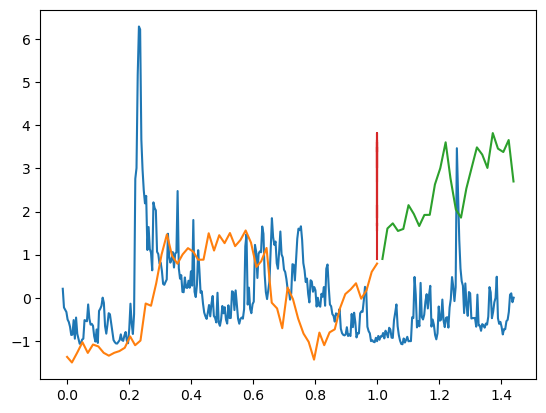

In [14]:
plt.plot(Ax, Ay)
plt.plot(Bx, By)
plt.plot(Xtest, ytest)
plt.show()

In [15]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(8, 4))
    Xtest = np.linspace(0, 1, 100)[:, None]
    (line,) = plt.plot(Ax, Ay, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y1")

    (line,) = plt.plot(Bx, By, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")
    ivs = m.inducing_variable.Z.numpy() 
    plt.scatter(ivs, np.zeros_like(ivs))
    plt.xlim([0, 1.2])
    plt.legend()
    return mu


def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()
 

In [ ]:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern12(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
probs = np.array([0.5, 0.5])
ivs = np.linspace(0, 1, 100).reshape(-1, 1)
iv_ind = np.random.choice([0, 1], p=probs, size=len(ivs)).reshape(-1, 1)
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg
m = SparseCMOGP((X, y), kernel=kern, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value       │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.0         │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.0         │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────┤
│ SparseCMOGP

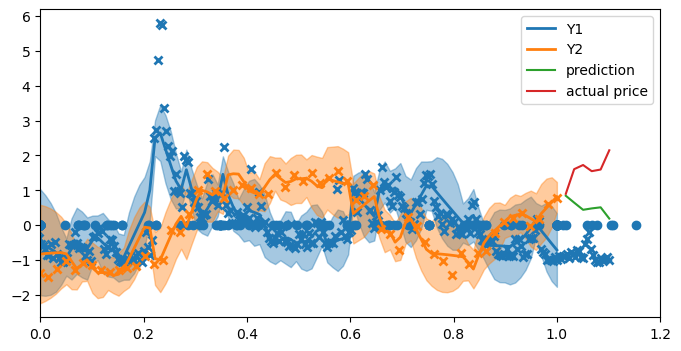

1.4559539532671788


In [ ]:
plot(m)
mu, var = m.predict_f(Xtest)
plt.plot(Xtest[:,0], mu, label="prediction")
plt.plot(Xtest[:,0], ytest, label="actual price")
plt.legend()
plt.show()
print(np.mean((mu - ytest)**2))


In [ ]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern12(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = gpf.likelihoods.SwitchedLikelihood(
    [gpf.likelihoods.Gaussian(), gpf.likelihoods.Gaussian()]
)

ivs = np.linspace(0, 1, 100).reshape(-1, 1)
ivs = np.hstack((ivs, np.random.choice([0, 1], p=[0.5, 0.5], size=len(ivs)).reshape(-1, 1)))

# now build the GP model as normal
m = gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=ivs)

# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss_closure((X, y)),
    m.trainable_variables,
    method="L-BFGS-B",
)

2026-04-14 18:12:59.746642: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-04-14 18:12:59.781224: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 336.13507168243945
        x: [-7.694e-01 -2.241e+00 ... -1.137e+00 -1.630e+00]
      nit: 2620
      jac: [ 6.229e-01  9.721e-01 ... -8.256e-01  4.264e-02]
     nfev: 3732
     njev: 3732
 hess_inv: <5358x5358 LbfgsInvHessProduct with dtype=float64>

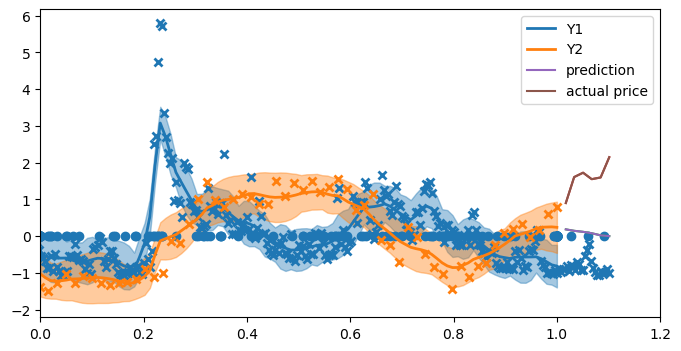

2.4177640740900794


In [ ]:
plot(m)
mu, var = m.predict_f(Xtest)
plt.plot(Xtest[:,0], mu)
plt.plot(Xtest[:,0], ytest)
plt.plot(Xtest[:,0], mu, label="prediction")
plt.plot(Xtest[:,0], ytest, label="actual price")
plt.legend()
plt.show()
print(np.mean((mu - ytest)**2))